In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd




sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

df = pd.read_csv("us.csv")

df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['Year'] = df['Start_Time'].dt.year
df['Month'] = df['Start_Time'].dt.month
df['Hour'] = df['Start_Time'].dt.hour

### Statistiques descriptives géographique:
 - Interprétation : La majorité des accidents se concentrent dans certaines zones géographiques (ex: zones urbaines).

In [6]:
df[['Start_Lat', 'Start_Lng']].describe()


,Start_Lat,Start_Lng
count,500000.000000,500000.000000
mean,35.929426,-97.590381
std,5.032482,18.280944
min,25.433098,-123.813927
25%,32.811352,-118.096634
50%,34.247250,-95.543968
75%,40.134354,-81.565750
max,48.199970,-70.571518


### Kruskal-Wallis: Sévérité par État
Top 5 états pour comparer

C:\Users\HAJAR\AppData\Local\Temp\ipykernel_13592\2922367269.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='State', y='Severity', data=df_top, palette='Set2')


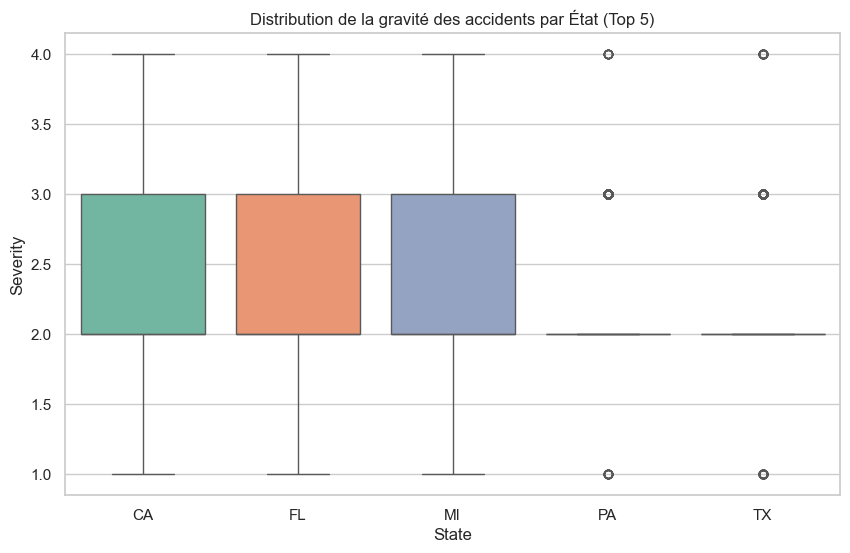

In [16]:
# Top 5 États
top_states = df['State'].value_counts().head(5).index
df_top = df[df['State'].isin(top_states)]

# Boxplot Severity par État
plt.figure(figsize=(10,6))
sns.boxplot(x='State', y='Severity', data=df_top, palette='Set2')
plt.title("Distribution de la gravité des accidents par État (Top 5)")
plt.ylabel("Severity")
plt.xlabel("State")
plt.show()

### Corrélations avec Severity

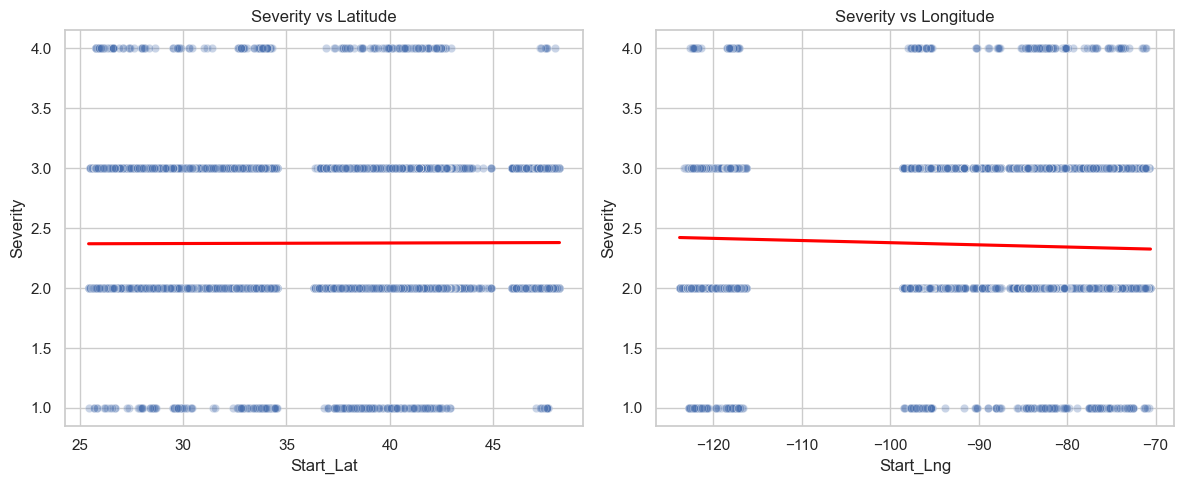

In [17]:

plt.figure(figsize=(12,5))

# Latitude vs Severity
plt.subplot(1,2,1)
sns.scatterplot(x='Start_Lat', y='Severity', data=df, alpha=0.3)
sns.regplot(x='Start_Lat', y='Severity', data=df, scatter=False, color='red')
plt.title("Severity vs Latitude")
plt.xlabel("Start_Lat")
plt.ylabel("Severity")

# Longitude vs Severity
plt.subplot(1,2,2)
sns.scatterplot(x='Start_Lng', y='Severity', data=df, alpha=0.3)
sns.regplot(x='Start_Lng', y='Severity', data=df, scatter=False, color='red')
plt.title("Severity vs Longitude")
plt.xlabel("Start_Lng")
plt.ylabel("Severity")

plt.tight_layout()
plt.show()

### ANOVA géographique

C:\Users\HAJAR\AppData\Local\Temp\ipykernel_13592\666522608.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\HAJAR\AppData\Local\Temp\ipykernel_13592\666522608.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


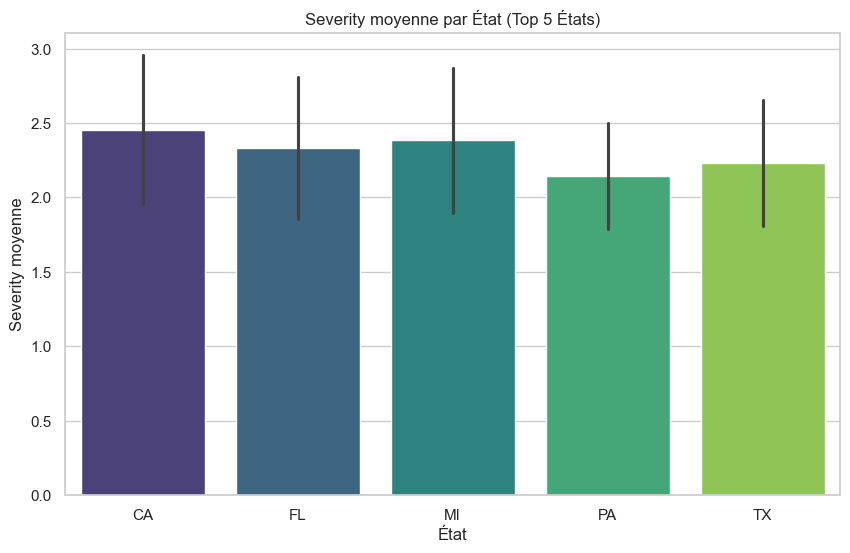

In [18]:

plt.figure(figsize=(10,6))

# Barplot de la moyenne Severity par Etat
sns.barplot(
    x='State', 
    y='Severity', 
    data=df[df['State'].isin(top_states)],
    ci='sd',      # écart-type représenté par les barres d'erreur
    palette='viridis'
)

plt.title("Severity moyenne par État (Top 5 États)")
plt.ylabel("Severity moyenne")
plt.xlabel("État")
plt.show()

### Régression logistique (Accident grave)

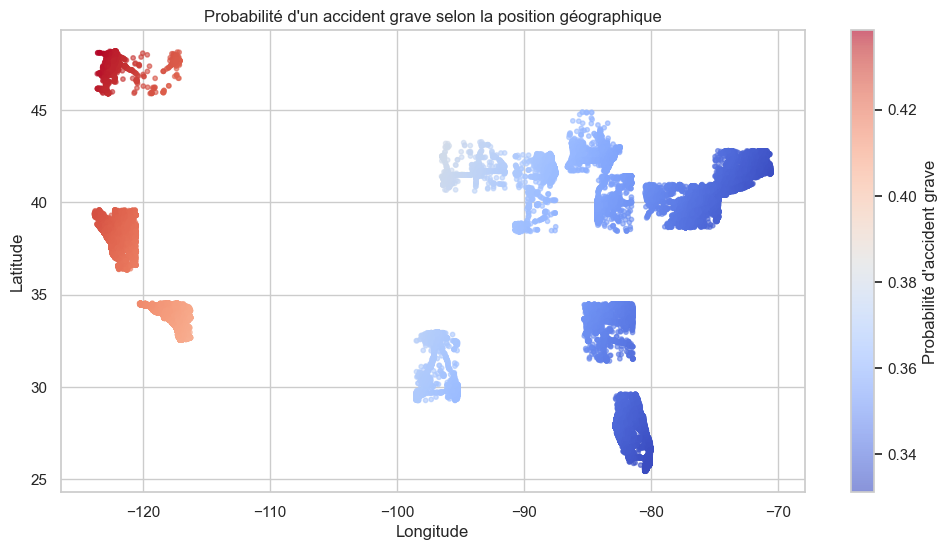

In [19]:
# Ajouter prédictions (probabilité) dans le dataframe
df['Severe_Prob'] = logit_model.predict(sm.add_constant(df[['Start_Lat','Start_Lng']]))

# Scatter plot Latitude vs Longitude, color = probabilité d'accident grave
plt.figure(figsize=(12,6))
plt.scatter(
    df['Start_Lng'], 
    df['Start_Lat'], 
    c=df['Severe_Prob'], 
    cmap='coolwarm', 
    alpha=0.6, 
    s=10
)
plt.colorbar(label="Probabilité d'accident grave")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Probabilité d'un accident grave selon la position géographique")
plt.show()

### ACP (Géographie + météo)

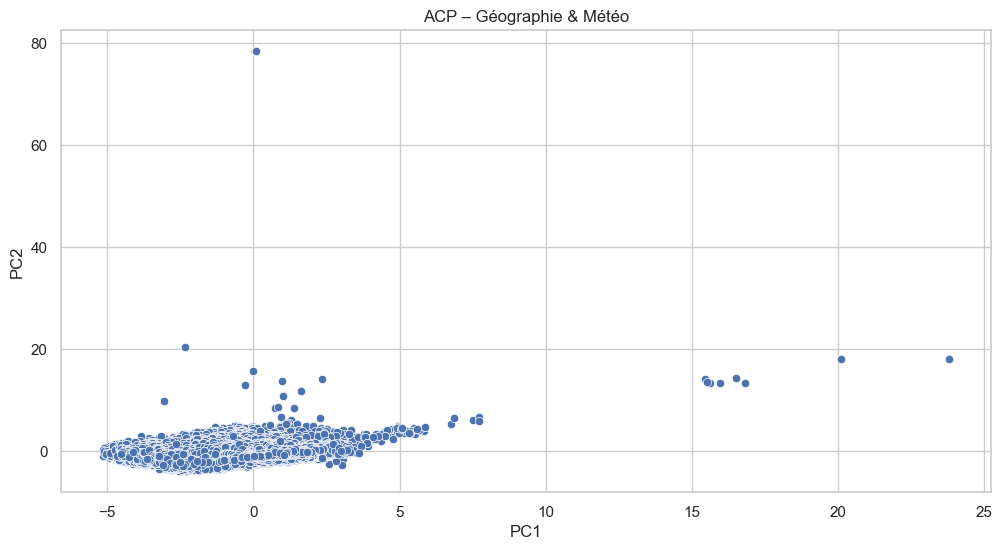

In [12]:
features = ['Start_Lat','Start_Lng','Temperature(C)','Humidity(%)','Wind_Speed(mph)','Visibility(mi)']
X = df[features].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=['PC1','PC2'])
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title("ACP – Géographie & Météo")
plt.show()

### MANOVA (State vs Severity + Distance)

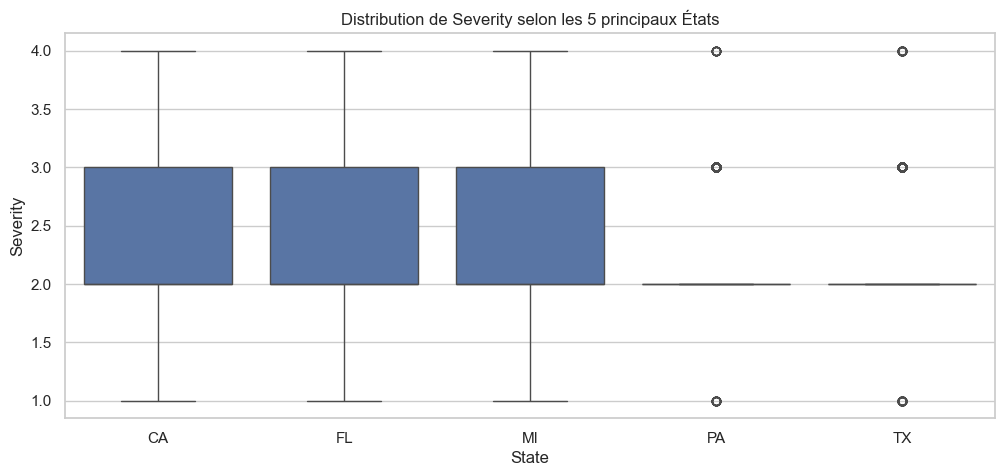

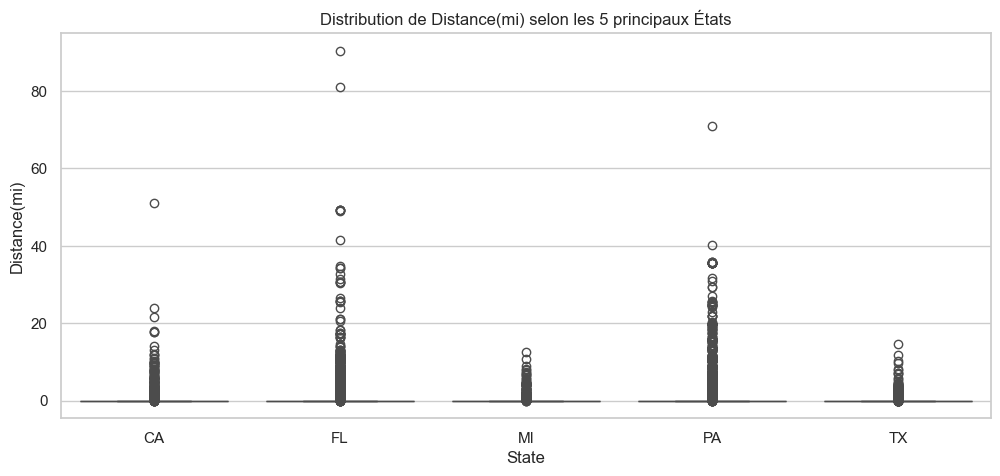

In [20]:
# Boxplot Severity par Etat
plt.figure(figsize=(12,5))
sns.boxplot(x='State', y='Severity', data=df[df['State'].isin(top_states)])
plt.title("Distribution de Severity selon les 5 principaux États")
plt.show()

# Boxplot Distance par Etat
plt.figure(figsize=(12,5))
sns.boxplot(x='State', y='Distance(mi)', data=df[df['State'].isin(top_states)])
plt.title("Distribution de Distance(mi) selon les 5 principaux États")
plt.show()

### Distribution des latitudes des accidents

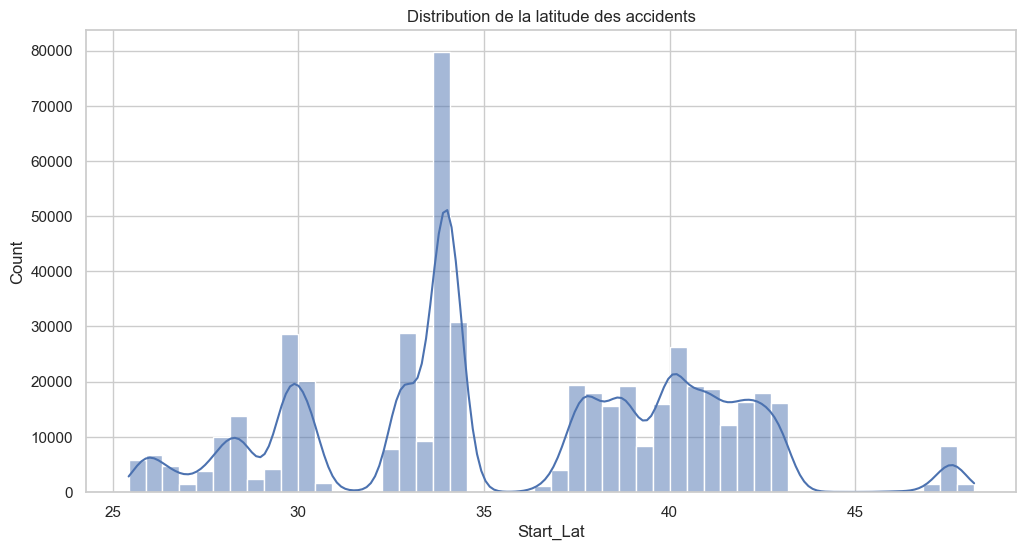

In [20]:

sns.histplot(df['Start_Lat'], bins=50, kde=True)
plt.title("Distribution de la latitude des accidents")
plt.show()


### Série temporelle par État

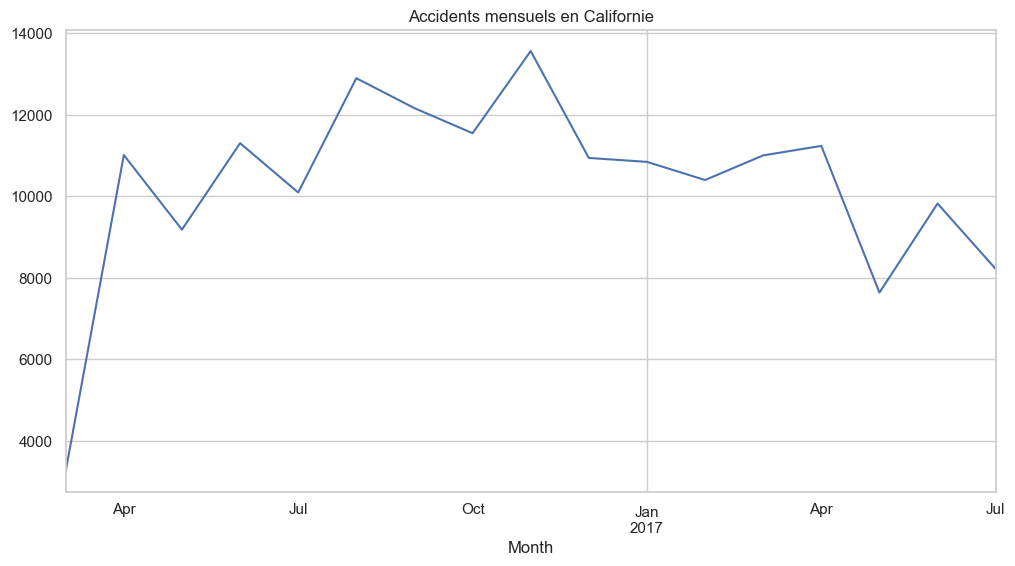

In [28]:
df['Month'] = df['Start_Time'].dt.to_period('M')

ts = df[df['State'] == 'CA'].groupby('Month').size()
ts.plot()
plt.title("Accidents mensuels en Californie")
plt.show()
